In [1]:
import cooler
import cooltools
import coolpuppy as coolpup
from coolpuppy import coolpup
from coolpuppy.lib.numutils import get_enrichment
import numpy as np
from matplotlib.ticker import EngFormatter
import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm
import glob
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt
import os
import pandas as pd
import bioframe
from joblib import Memory
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
clr_path = {
       "GSC": "data/G1.mcool",
      "Neuron": "neuron.mcool",
     "Glia": "glia.mcool",
     "iPSC": "data/Choi_zoomed.mcool",
}
cts = list(clr_path.keys()) 

res = 25_000 
clrs = {ct: cooler.Cooler(clr_path[ct] + f'::resolutions/{res}') 
        for ct in cts}

In [3]:
clrs

{'GSC': <Cooler "G1.mcool::/resolutions/25000">,
 'Neuron': <Cooler "neuron.mcool::/resolutions/25000">,
 'Glia': <Cooler "glia.mcool::/resolutions/25000">,
 'iPSC': <Cooler "Choi_zoomed.mcool::/resolutions/25000">}

In [4]:
# !cooler balance ../GSE185192_NPC_HiC_MaE.mcool::/resolutions/25000 -p 10

In [9]:
trans = {chrom: f"chr{chrom}" for chrom in clr.chromnames if not chrom.startswith("chr")}
cooler.rename_chroms(clr, trans)
# print(f'chromosomes: {clr.chromnames}, binsize: {clr.binsize}') 

In [5]:
hg38_chromsizes = bioframe.fetch_chromsizes('hg38')
hg38_cens = bioframe.fetch_centromeres('hg38')
hg38_arms = bioframe.make_chromarms(hg38_chromsizes, hg38_cens)
hg38_arms.head()

,chrom,start,end,name
0,chr1,0,123400000,chr1_p
1,chr1,123400000,248956422,chr1_q
2,chr2,0,93900000,chr2_p
3,chr2,93900000,242193529,chr2_q
4,chr3,0,90900000,chr3_p


In [6]:
bedpe_file = "/tank/projects/iuliia_parshchikova/data/polycomb_dot_anchors.hand_made.filt_by_fithic.bedpe"
loops = pd.read_csv(bedpe_file, sep='\t')
loops_hg38 = pd.DataFrame(loops, columns=['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2'])
loops_hg38.head()

,chrom1,start1,end1,chrom2,start2,end2
0,chr15,36800000,36900000,chr15,52700000,52800000
1,chr15,37000000,37100000,chr15,52700000,52800000
2,chr15,36800000,36900000,chr15,59900000,60000000
3,chr15,37000000,37100000,chr15,59900000,60000000
4,chr15,52700000,52800000,chr15,59900000,60000000


In [7]:
expected_dict = {}
for ct, clr in clrs.items():
    valid_chroms = set(clr.chromnames)
    hg38_arms = hg38_arms[hg38_arms.chrom.isin(valid_chroms)]
    expected_dict[ct] = cooltools.expected_cis(clr, view_df=hg38_arms, nproc=10)
    #expected.to_csv(f"data/expected_{ct}.csv", index=False)

INFO:root:creating a Pool of 10 workers
INFO:root:creating a Pool of 10 workers
INFO:root:creating a Pool of 10 workers
INFO:root:creating a Pool of 10 workers


In [8]:
pileups = {}
for ct, clr in clrs.items():
    #expected_df = pd.read_csv(f"data/expected_{ct}_John.csv")
    stack = cooltools.pileup(clr, loops_hg38, 
                             view_df=hg38_arms, expected_df=expected_dict[ct], 
                             flank=400_000, nproc=10)
    
    pileups[ct] = np.nanmean(stack, axis=0)

INFO:root:creating a Pool of 10 workers
/home/iuliia_parshchikova/miniconda3/envs/hic_pipeline/lib/python3.10/site-packages/cooltools/api/snipping.py:259: UserWarning: Some features do not have view regions assigned! Some snips will be empty.
  warnings.warn(
/home/iuliia_parshchikova/miniconda3/envs/hic_pipeline/lib/python3.10/site-packages/cooltools/api/snipping.py:674: RuntimeWarning: invalid value encountered in divide
  return snippet / e
/home/iuliia_parshchikova/miniconda3/envs/hic_pipeline/lib/python3.10/site-packages/cooltools/api/snipping.py:674: RuntimeWarning: invalid value encountered in divide
  return snippet / e
/home/iuliia_parshchikova/miniconda3/envs/hic_pipeline/lib/python3.10/site-packages/cooltools/api/snipping.py:674: RuntimeWarning: invalid value encountered in divide
  return snippet / e
INFO:root:creating a Pool of 10 workers
/home/iuliia_parshchikova/miniconda3/envs/hic_pipeline/lib/python3.10/site-packages/cooltools/api/snipping.py:259: UserWarning: Some fea

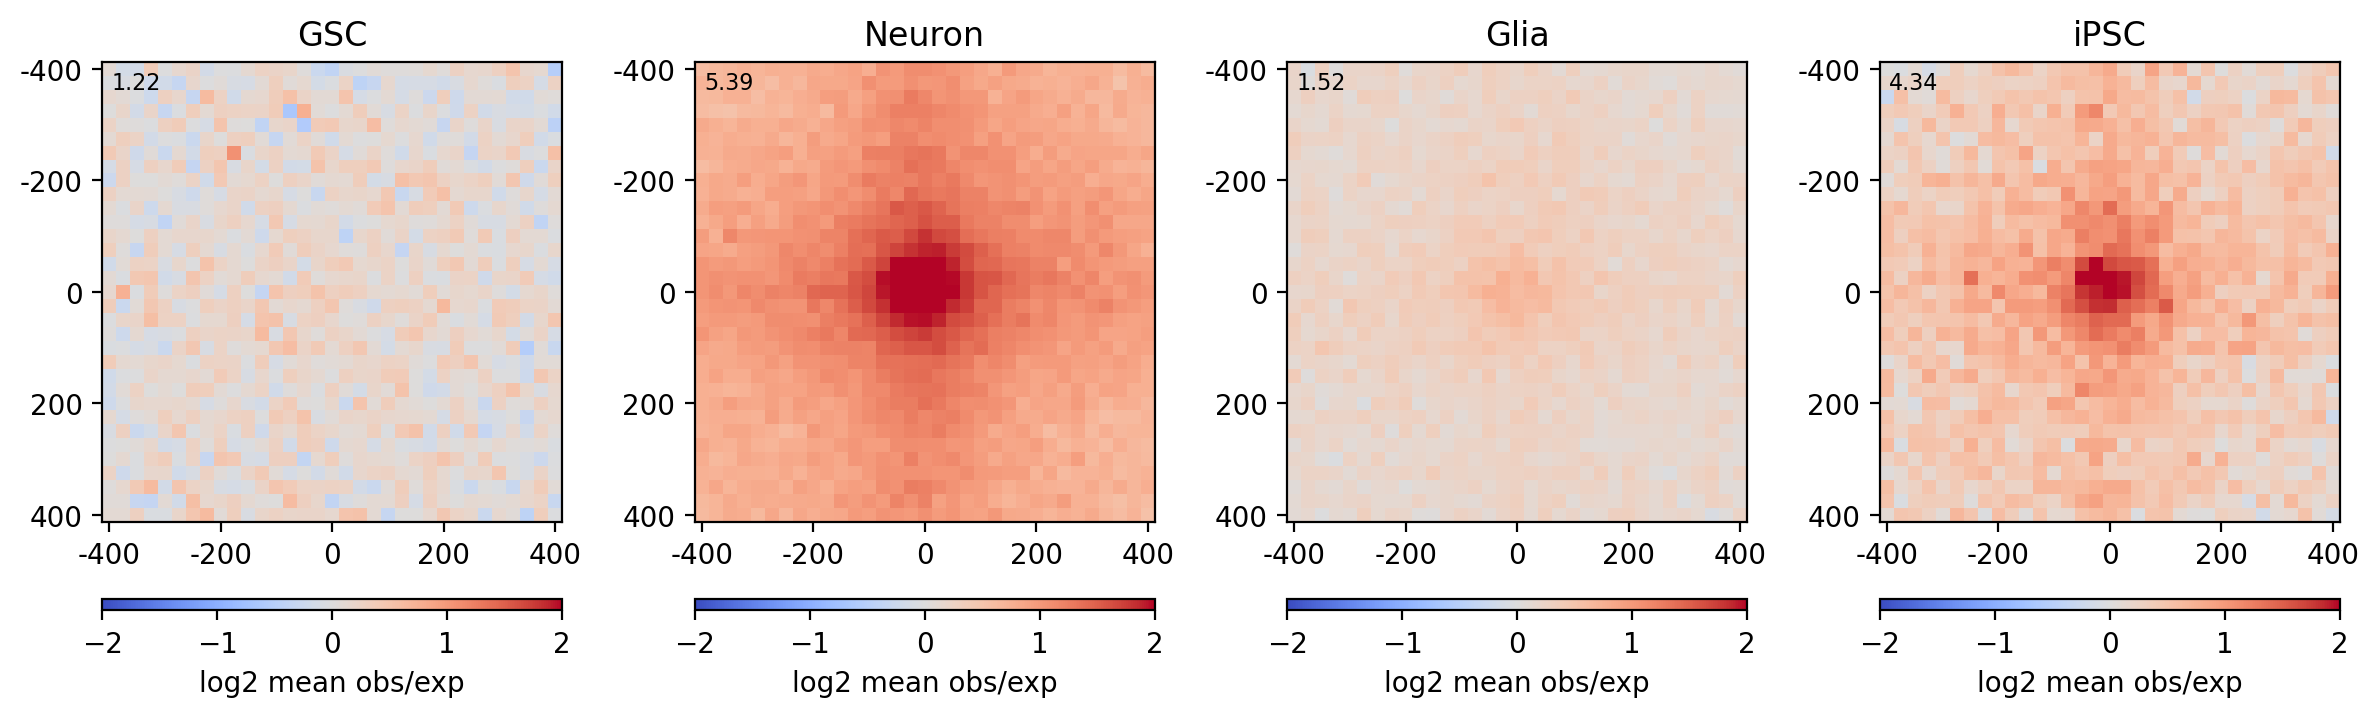

In [9]:
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(12, 10), dpi=200)
axs = axs.flatten()

flank = 400_000
res = 25000  
for ax, (ct, mtx) in zip(axs, pileups.items()):
    im = ax.imshow(np.log2(mtx),
                   vmax=2, vmin=-2,
                   cmap='coolwarm')

    ax.set_title(f'{ct}')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("bottom", size="10%", pad=0.3, aspect=0.1)
    cbar = plt.colorbar(im, cax=cax, label='log2 mean obs/exp', orientation='horizontal')

    ticks_pixels = np.linspace(0, flank*2//res, 5)
    ticks_kbp = ((ticks_pixels - ticks_pixels[-1]/2) * res // 1000).astype(int)

    ax.set_xticks(ticks_pixels)
    ax.set_xticklabels(ticks_kbp)
    ax.set_yticks(ticks_pixels)
    ax.set_yticklabels(ticks_kbp)

    en = get_enrichment(mtx, 0)
    ax.text(0.02, 0.98, f'{en:.2f}', va='top',
            transform=ax.transAxes, fontsize=8)
plt.tight_layout()
plt.show()